# Strand D (missingness mechanism), deepened: a direct audit of unscanned domains

**Contribution.** Strands B and D characterized the domains Blacklight never
scanned *indirectly* (tracker-list membership, HTTP Archive presence, Wayback
liveness). This notebook looks at them *directly*: a seeded random sample of
200 unscanned domains — 100 drawn proportional to panel visits (what a
typical unscanned **visit** lands on), 100 drawn uniformly (what a typical
unscanned **domain** is) — each hand-coded against a written rubric
(`CODING_RUBRIC.md`), probed for current status, and re-scanned with
Blacklight in July 2026. The point is measurement, not advocacy: every
section reports what the sample says, in whichever direction it points.

Inputs are produced by `01_parse_scan_errors.py` → `02_draw_audit_sample.py`
→ `03_probe_and_rescan.py` → `04_code_sample.py`.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

sys.path.insert(0, os.path.abspath(".."))

import config
from utilities import pandas_to_tex, save_mpl_fig

MEASURES4 = [
    ("ddg_join_ads", "Ad trackers"),
    ("third_party_cookies", "Third-party cookies"),
    ("fb_pixel", "Facebook Pixel"),
    ("google_analytics", "Google Analytics"),
]
KEYS = [k for k, _ in MEASURES4]

GRAYS = ["0.2", "0.5", "0.8"]
BOOT_SEED = 20250114  # bootstrap seed


def wilson(k, n):
    lo, hi = proportion_confint(k, n, method="wilson")
    return lo, hi


def boot_ci(x, n_boot=10_000, seed=BOOT_SEED):
    x = np.asarray(x, dtype=float)
    # Build the generator here rather than drawing from a module-level one.
    # A shared generator is consumed across calls, so re-running this cell
    # without re-running the cell that created it produced different
    # intervals each time -- and these intervals are published.
    rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    return np.percentile(means, [2.5, 97.5])

Checking that all paths exist:
{'web_mobile': False, 'web_desktop': False, 'web': False, 'yg_profile': False, 'blacklight': False, 'who': False}


In [2]:
coded = pd.read_csv(config.FP_AUDIT_CODED)
reasons = pd.read_csv(config.FP_FAILURE_REASONS)

yg = pd.read_csv(config.FP_YG_IND_DOMAIN)
dom = (
    yg.groupby("private_domain")
    .agg(visits=("visits", "sum"))
    .reset_index()
)
bl = pd.read_csv(config.FP_BLACKLIGHT)
bl["private_domain"] = bl["filename"].str.replace("_", ".", regex=False)
# filename underscores are ambiguous for multi-dot hosts; join on the same
# transform used everywhere else in the repo: domain -> filename
dom["filename"] = dom["private_domain"].str.replace(".", "_", regex=False)
pop = dom.merge(bl.drop(columns=["private_domain"]), on="filename", how="inner")

assert len(coded) == 200
assert coded["category"].isin(config.CATEGORIES).all()
n_scanned_today = int(coded["bl_scan_success"].sum())
print(f"scanned population (Jan 2025): {len(pop):,} domains")
print(f"audit sample scanned successfully (Jul 2026): {n_scanned_today}/200")

scanned population (Jan 2025): 34,078 domains
audit sample scanned successfully (Jul 2026): 131/200


## 1. Why scans failed (the full unscanned universe, not the sample)

Parsed from the original scraper's error log (`01_parse_scan_errors.py`).
Two distinct mechanisms matter: **`empty_groups`** (Blacklight's API
responded but produced nothing — bot walls, JS challenges, non-HTML) is a
*domain-side* property; **`api_network_error`** (the scraper's own
connection to the Blacklight API failed) is *scraper-side* and says nothing
about the domain — missingness from it is plausibly ignorable.

In [3]:
total_visits = dom["visits"].sum()
comp = (
    reasons.groupby("failure_reason")
    .agg(n_domains=("private_domain", "size"), visits=("visits", "sum"))
    .sort_values("visits", ascending=False)
)
comp["pct_unscanned_domains"] = 100 * comp["n_domains"] / len(reasons)
comp["pct_unscanned_visits"] = 100 * comp["visits"] / reasons["visits"].sum()
comp["pct_all_visits"] = 100 * comp["visits"] / total_visits
comp.round(1)

,n_domains,visits,pct_unscanned_domains,pct_unscanned_visits,pct_all_visits
failure_reason,,,,,
empty_groups,28581,1209077,95.3,82.3,19.4
site_unreachable,51,154177,0.2,10.5,2.5
api_network_error,1364,106481,4.5,7.2,1.7
not_in_error_log,1,22,0.0,0.0,0.0


## 2. What the unscanned domains are (coded sample)

Categories per `CODING_RUBRIC.md`; codes in
`data/selection_audit/codes_claude.csv` with per-domain rationales, a seeded
20-domain subset flagged for user adjudication. The **visits stratum**
estimates the composition of unscanned *visit mass*; the **uniform stratum**
estimates the composition of the unscanned *domain list*. Wilson 95% CIs.

In [4]:
rows = []
for cat in config.CATEGORIES:
    row = {"category": cat}
    for label, mask_col in [
        ("visits", "in_visits_stratum"),
        ("uniform", "in_uniform_stratum"),
    ]:
        sub = coded[coded[mask_col]]
        k, n = int((sub["category"] == cat).sum()), len(sub)
        lo, hi = wilson(k, n)
        row[f"{label}_n"] = k
        row[f"{label}_pct"] = 100 * k / n
        row[f"{label}_ci"] = f"[{100 * lo:.0f}, {100 * hi:.0f}]"
    rows.append(row)
composition = pd.DataFrame(rows).sort_values("visits_n", ascending=False)
composition

,category,visits_n,visits_pct,visits_ci,uniform_n,uniform_pct,uniform_ci
0,content_site,61,61.0,"[51, 70]",71,71.0,"[61, 79]"
1,adtech_infrastructure,20,20.0,"[13, 29]",3,3.0,"[1, 8]"
2,cdn_api_host,8,8.0,"[4, 15]",3,3.0,"[1, 8]"
5,dead,7,7.0,"[3, 14]",15,15.0,"[9, 23]"
6,unknown,3,3.0,"[1, 8]",6,6.0,"[3, 12]"
4,adult_content,1,1.0,"[0, 5]",1,1.0,"[0, 5]"
3,parked_or_forsale,0,0.0,"[0, 4]",1,1.0,"[0, 5]"


In [5]:
tex = composition.copy()
tex["category"] = tex["category"].str.replace("_", r"\_", regex=False)
for s in ["visits", "uniform"]:
    tex[f"{s}_pct"] = tex[f"{s}_pct"].map("{:.0f}".format)
pandas_to_tex(tex, os.path.join(config.TABLES_DIR, "selection_audit_composition"))
print("wrote tables/selection_audit_composition.tex")

wrote tables/selection_audit_composition.tex


## 3. Current status and scannability today

`probe_status` is from a July-2026 GET from the analyst's network
(`network_filtered` = intercepted by that network's own content filter, so
uninformative about the domain); `bl_scan_success` is whether The Markup's
Blacklight API — the same instrument that failed on all of these in
January 2025 — produced a scan in July 2026.

In [6]:
print(pd.crosstab(coded["probe_status"], coded["bl_scan_success"]))

rows = []
for label, mask_col in [("visits", "in_visits_stratum"), ("uniform", "in_uniform_stratum")]:
    sub = coded[coded[mask_col]]
    k, n = int(sub["bl_scan_success"].sum()), len(sub)
    lo, hi = wilson(k, n)
    rows.append(
        {"stratum": label, "scanned_today": f"{k}/{n}",
         "pct": round(100 * k / n), "ci95": f"[{100 * lo:.0f}, {100 * hi:.0f}]"}
    )
pd.DataFrame(rows)

bl_scan_success   False  True 
probe_status                  
dead                 50      7
http_error            3     11
live                 15     94
network_filtered      1      5
redirect              0     14


,stratum,scanned_today,pct,ci95
0,visits,63/100,63,"[53, 72]"
1,uniform,68/100,68,"[58, 76]"


In [7]:
by = (
    coded.groupby("category")["bl_scan_success"]
    .agg(scanned="sum", n="size")
    .assign(pct=lambda d: (100 * d.scanned / d.n).round())
    .sort_values("n", ascending=False)
)
print(by.to_string())
by2 = (
    coded.groupby("failure_reason")["bl_scan_success"]
    .agg(scanned="sum", n="size")
    .assign(pct=lambda d: (100 * d.scanned / d.n).round())
)
print()
print(by2.to_string())

                       scanned    n    pct
category                                  
content_site               107  132   81.0
adtech_infrastructure       10   23   43.0
dead                         1   22    5.0
cdn_api_host                 3   11   27.0
unknown                      7    9   78.0
adult_content                2    2  100.0
parked_or_forsale            1    1  100.0

                   scanned    n   pct
failure_reason                       
api_network_error        7   10  70.0
empty_groups           121  182  66.0
site_unreachable         3    8  38.0


## 4. Tracking on the unscanned domains, measured directly

For sampled domains Blacklight scans successfully today, we observe actual
tracking. Three comparisons, all on the Blacklight scale:

1. **Originally scanned population** (Jan 2025), visit-weighted — what the
   paper's non-missing half looks like per visit.
2. **Audit sample, visits stratum** — a direct estimate of tracking per
   unscanned visit (bootstrap 95% CI), conditional on 2026-scannability.
3. **Strand B's calibrated fill**, recomputed here the same way
   `httparchive/07_coverage_bounds` builds it (E[Blacklight | HTTP-Archive
   presence] on jointly measured domains), applied to the same audit
   domains — a check of whether the imputation model predicts what direct
   measurement finds.

Caveats stated up front: (i) domains scannable in 2026 are a selected subset
of the unscanned pool; (ii) the fresh scans measure July-2026 tracking, and
strand A shows 2025→2022 drift is modest but nonzero; (iii) the visits
stratum weights by June-2022 visits.

In [8]:
ha22 = (
    pd.read_csv(config.FP_HA_DOMAIN_MEASURES)
    .query("crawl == 'panel'")
    .groupby("private_domain")[KEYS]
    .mean()
)
joint = pop.merge(ha22, left_on="private_domain", right_index=True,
                  how="left", suffixes=("", "_ha"))
# Visit-weighted, exactly as httparchive/07_coverage_bounds computes its
# calibration (wmean over the jointly measured set with visit weights).
fills = {}
for k in KEYS:
    measured = joint[f"{k}_ha"].notna()
    present = joint[f"{k}_ha"].fillna(0) > 0
    fills[k] = {
        True: np.average(
            joint.loc[measured & present, k],
            weights=joint.loc[measured & present, "visits"],
        ),
        False: np.average(
            joint.loc[measured & ~present, k],
            weights=joint.loc[measured & ~present, "visits"],
        ),
    }
print("calibrated fills E[BL count | HA presence], visit-weighted as in 07:")
print(pd.DataFrame(fills).round(2))

calibrated fills E[BL count | HA presence], visit-weighted as in 07:
       ddg_join_ads  third_party_cookies  fb_pixel  google_analytics
True            7.1                 8.10      0.11              0.01
False           1.6                 1.67      0.03              0.00


In [9]:
# The visits stratum was drawn PPS *without* replacement (02_draw_audit_sample.py
# uses rng.choice(replace=False, p=visits/sum)). An unweighted mean is the
# Hansen-Hurwitz estimator, unbiased for the visit-weighted population mean only
# under PPS *with* replacement, so a design correction is needed.
#
# The correction previously used pi_i = min(n*p_i, 1). That formula is WRONG for
# this design. numpy's replace=False with p is *successive* sampling: it draws
# one unit, renormalises the remaining probabilities, and repeats. Its inclusion
# probabilities have no closed form and are not min(n*p_i, 1). The arithmetic
# says so immediately -- any fixed-size-n design must satisfy sum(pi_i) = n, and
# sum(min(n*p_i, 1)) = 91.10, not 100. Nor are the seven large units certainties:
# under the actual design their pi are 0.999 down to 0.729.
#
# So estimate pi by Monte Carlo over the same design, and gate on sum(pi) = n.
# This is slower than a formula but it is the design that was actually run.
#
# The estimator is Hajek (ratio form), the standard choice when realised weights
# do not sum to the known total -- here they cannot, because only 63 of the 100
# drawn domains rescanned successfully. That makes the estimate conditional on
# being scannable in 2026, which is the paper's own selection problem and is not
# fixed by reweighting.
pool_visits = (
    yg[~yg["private_domain"].isin(set(pop["private_domain"]))]
    .groupby("private_domain")["visits"].sum()
)
V_pool, n_draw = pool_visits.sum(), 100

PI_REPS = 200_000
p_draw = (pool_visits / V_pool).to_numpy()
_rng = np.random.default_rng(config.SAMPLE_SEED)
_counts = np.zeros(len(p_draw))
for _ in range(PI_REPS):
    _counts[_rng.choice(len(p_draw), size=n_draw, replace=False, p=p_draw)] += 1
pi = pd.Series(_counts / PI_REPS, index=pool_visits.index)

if abs(pi.sum() - n_draw) > 0.5:
    raise ValueError(
        f"simulated inclusion probabilities sum to {pi.sum():.2f}, not {n_draw}; "
        "the simulated design is not the one that drew the sample"
    )
print(f"simulated pi over {PI_REPS:,} draws: sum = {pi.sum():.3f} (must be {n_draw})")
print(f"  formula min(n*p, 1) would have summed to "
      f"{np.minimum(n_draw * p_draw, 1.0).sum():.2f} -- the reason it was wrong")
print(f"  largest pi: {', '.join(f'{v:.3f}' for v in pi.nlargest(7))}")

scanned_now = coded[coded["bl_scan_success"] & coded["in_visits_stratum"]]
scanned_uni = coded[coded["bl_scan_success"] & coded["in_uniform_stratum"]]

w_ht = (
    pool_visits.reindex(scanned_now["private_domain"]).to_numpy()
    / pi.reindex(scanned_now["private_domain"]).to_numpy()
)
print(f"visits stratum: {len(scanned_now)} rescanned")


def hajek(y, w):
    y = np.asarray(y, dtype=float)
    return float(np.sum(w * y) / np.sum(w))


def boot_ci_w(y, w, n_boot=10_000, seed=BOOT_SEED):
    """Percentile interval resampling the sampled units with their weights."""
    rng = np.random.default_rng(seed)
    y, w = np.asarray(y, dtype=float), np.asarray(w, dtype=float)
    idx = rng.integers(0, len(y), size=(n_boot, len(y)))
    draws = (y[idx] * w[idx]).sum(axis=1) / w[idx].sum(axis=1)
    return np.percentile(draws, [2.5, 97.5])


# HA-presence per audit domain, for the strand-B-style prediction
aud_ha = ha22.reindex(coded["private_domain"]).set_axis(coded.index)

rows = []
for k, label in MEASURES4:
    pop_mean = np.average(pop[k], weights=pop["visits"])
    x = scanned_now[f"bl_{k}"].astype(float)
    unwtd = x.mean()
    est = hajek(x, w_ht)
    lo, hi = boot_ci_w(x, w_ht)

    # Strand B only ever fills domains HTTP Archive actually measured; where it
    # did not measure, 07_coverage_bounds uses the assumption fill, never the
    # HA-absent conditional mean. Mapping .fillna(0) > 0 here handed every
    # unmeasured domain the HA-absent value instead, so the column was a blend
    # of the fill and a value strand B never assigns. Restrict the comparison to
    # the domains strand B actually speaks about, and report the matching direct
    # estimate on that same subset so the two columns compare like with like.
    measured = aud_ha.loc[scanned_now.index, k].notna().to_numpy()
    pres = aud_ha.loc[scanned_now.index, k][measured] > 0
    pred = pres.map(fills[k]).mean()
    direct_on_measured = hajek(x.to_numpy()[measured], w_ht[measured])

    rows.append(
        {
            "measure": label,
            "scanned_pop_visitwtd": round(pop_mean, 2),
            "audit_direct_mean": round(est, 2),
            "audit_ci95": f"[{lo:.2f}, {hi:.2f}]",
            "strandB_predicted": round(pred, 2),
            "strandB_direct_same": round(direct_on_measured, 2),
            "n_strandB": int(measured.sum()),
            "n_audit": len(x),
            "uniform_mean": round(scanned_uni[f"bl_{k}"].mean(), 2),
            "unweighted_mean": round(unwtd, 2),
        }
    )
tracking = pd.DataFrame(rows)
print("\nDesign-weighted vs unweighted, and the strand-B check on its own subset:")
for r in tracking.itertuples():
    print(f"  {r.measure:22s} Hajek {r.audit_direct_mean:6.2f}  "
          f"unwtd {r.unweighted_mean:6.2f} | strand-B predicts "
          f"{r.strandB_predicted:5.2f} vs direct {r.strandB_direct_same:6.2f} "
          f"on n={r.n_strandB}")
tracking

simulated pi over 200,000 draws: sum = 100.000 (must be 100)
  formula min(n*p, 1) would have summed to 91.10 -- the reason it was wrong
  largest pi: 0.999, 0.939, 0.929, 0.868, 0.858, 0.745, 0.728
visits stratum: 63 rescanned

Design-weighted vs unweighted, and the strand-B check on its own subset:
  Ad trackers            Hajek   8.11  unwtd   8.81 | strand-B predicts  6.97 vs direct  11.02 on n=43
  Third-party cookies    Hajek   9.45  unwtd  10.46 | strand-B predicts  6.93 vs direct  14.68 on n=33
  Facebook Pixel         Hajek   0.09  unwtd   0.10 | strand-B predicts  0.09 vs direct   0.11 on n=43
  Google Analytics       Hajek   0.27  unwtd   0.29 | strand-B predicts  0.01 vs direct   0.32 on n=43


,measure,scanned_pop_visitwtd,audit_direct_mean,audit_ci95,strandB_predicted,strandB_direct_same,n_strandB,n_audit,uniform_mean,unweighted_mean
0,Ad trackers,6.52,8.11,"[4.63, 12.27]",6.97,11.02,43,63,8.04,8.81
1,Third-party cookies,7.69,9.45,"[4.43, 15.96]",6.93,14.68,33,63,10.82,10.46
2,Facebook Pixel,0.09,0.09,"[0.03, 0.16]",0.09,0.11,43,63,0.22,0.10
3,Google Analytics,0.01,0.27,"[0.16, 0.38]",0.01,0.32,43,63,0.38,0.29


wrote tables/selection_audit_tracking.tex


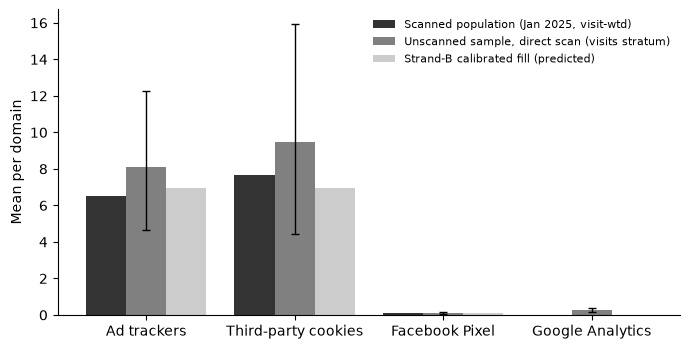

In [10]:
# unweighted_mean and n_audit stay out of the tex to keep the manuscript
# tabular at eight columns; both remain in the notebook display above so the
# design correction and the sample size stay visible.
pandas_to_tex(
    tracking.drop(columns=["unweighted_mean", "n_audit"]).astype(str),
    os.path.join(config.TABLES_DIR, "selection_audit_tracking"),
)
print("wrote tables/selection_audit_tracking.tex")

fig, ax = plt.subplots(figsize=(7, 3.6))
xpos = np.arange(len(MEASURES4))
w = 0.27
ax.bar(xpos - w, tracking["scanned_pop_visitwtd"], w,
       color=GRAYS[0], label="Scanned population (Jan 2025, visit-wtd)")
ax.bar(xpos, tracking["audit_direct_mean"], w,
       color=GRAYS[1], label="Unscanned sample, direct scan (visits stratum)")
err = np.array([
    [m - float(ci.strip("[]").split(",")[0]) for m, ci in
     zip(tracking["audit_direct_mean"], tracking["audit_ci95"])],
    [float(ci.strip("[]").split(",")[1]) - m for m, ci in
     zip(tracking["audit_direct_mean"], tracking["audit_ci95"])],
])
ax.errorbar(xpos, tracking["audit_direct_mean"], yerr=err,
            fmt="none", ecolor="black", capsize=3, lw=1)
ax.bar(xpos + w, tracking["strandB_predicted"], w,
       color=GRAYS[2], label="Strand-B calibrated fill (predicted)")
ax.set_xticks(xpos)
ax.set_xticklabels([label for _, label in MEASURES4])
ax.set_ylabel("Mean per domain")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
save_mpl_fig(os.path.join(config.FIGURES_DIR, "selection_audit_tracking"))
plt.show()

## 5. Reading the results

The cell below assembles the numbers the summary paragraph should quote;
interpretation follows from whatever they show.

In [11]:
vis = coded[coded["in_visits_stratum"]]
uni = coded[coded["in_uniform_stratum"]]

summary = {
    "visits-stratum: user-facing content (content_site+adult) %": round(
        100 * vis["category"].isin(["content_site", "adult_content"]).mean()
    ),
    "visits-stratum: tracker/CDN infrastructure %": round(
        100 * vis["category"].isin(["adtech_infrastructure", "cdn_api_host"]).mean()
    ),
    "uniform-stratum: user-facing content %": round(
        100 * uni["category"].isin(["content_site", "adult_content"]).mean()
    ),
    "uniform-stratum: dead/unknown %": round(
        100 * uni["category"].isin(["dead", "unknown"]).mean()
    ),
    "scannable today, visits stratum %": round(
        100 * vis["bl_scan_success"].mean()
    ),
    "scannable today, uniform stratum %": round(
        100 * uni["bl_scan_success"].mean()
    ),
    "ads: scanned population visit-wtd mean": float(
        tracking.loc[tracking.measure == "Ad trackers", "scanned_pop_visitwtd"].iloc[0]
    ),
    "ads: unscanned direct mean (visits stratum)": float(
        tracking.loc[tracking.measure == "Ad trackers", "audit_direct_mean"].iloc[0]
    ),
    "ads: strand-B predicted for same domains": float(
        tracking.loc[tracking.measure == "Ad trackers", "strandB_predicted"].iloc[0]
    ),
}
for k, v in summary.items():
    print(f"{k:55}: {v}")

visits-stratum: user-facing content (content_site+adult) %: 62
visits-stratum: tracker/CDN infrastructure %           : 28
uniform-stratum: user-facing content %                 : 72
uniform-stratum: dead/unknown %                        : 21
scannable today, visits stratum %                      : 63
scannable today, uniform stratum %                     : 68
ads: scanned population visit-wtd mean                 : 6.52
ads: unscanned direct mean (visits stratum)            : 8.11
ads: strand-B predicted for same domains               : 6.97
